## FEATURE ENGINEERING

- Data in: `data/processed/bank-full-cleaned-processed.csv`

- Data out: `data/processed/bank-full-cleaned-processed-featured.csv`

### Bucketization

Several variables in the dataset are continuous and not well suited for segmentation analysis. Therefore, discretization is applied to transform these variables into categorical buckets:

- `balance`
- `age`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# load data to df
ROOT = Path().resolve().parents[0]
PROCESSED_DATA_PATH = ROOT / "data" / "processed" / "bank-full-cleaned-processed.csv"
df = pd.read_csv(PROCESSED_DATA_PATH, sep = ",")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0


Explore the `balance` variable

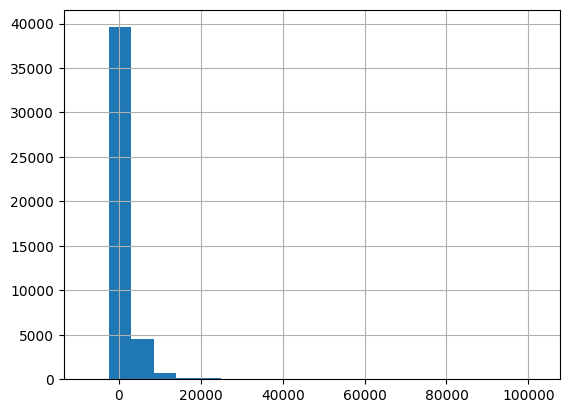

In [10]:
df['balance'].hist(bins=20)
plt.show()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64


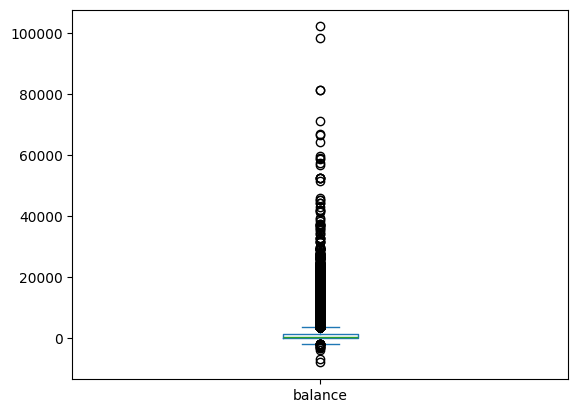

In [2]:
print(df['balance'].describe())
df['balance'].plot(kind='box')
plt.show()

The raw `balance` values are highly skewed and contain extreme positive and negative observations, which can lead to unstable or overly fragmented segments. Grouping balance into meaningful ranges (e.g., negative, low, medium, high) creates more stable and interpretable customer segments, allowing reliable comparison of conversion rates across financial profiles. Bucketing also reflects practical business usage, where customers are typically targeted based on broad financial capacity categories rather than precise account balances.

In [3]:
# Balance Bucketing
df['balance_bucket'] = pd.qcut(
    df.loc[df['balance'] >= 0, 'balance'],
    q=3,
    labels=['low','mid','high']
)

# Convert to object/string
df['balance_bucket'] = df['balance_bucket'].astype(object)

# Assign negative bucket
df.loc[df['balance'] < 0, 'balance_bucket'] = 'negative'

In [4]:
df['balance_bucket'].value_counts()

balance_bucket
low         13847
high        13814
mid         13784
negative     3766
Name: count, dtype: int64

Explore the `age` variable

<Axes: >

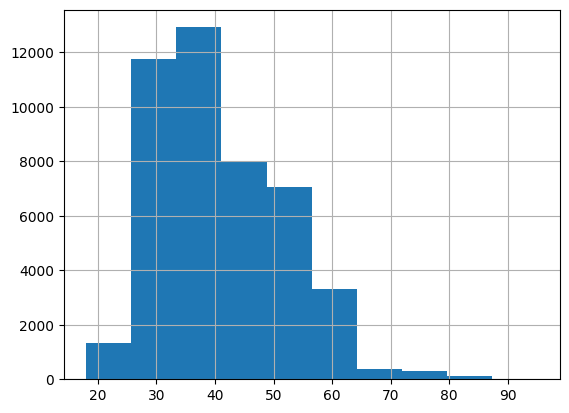

In [5]:
df['age'].hist()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64


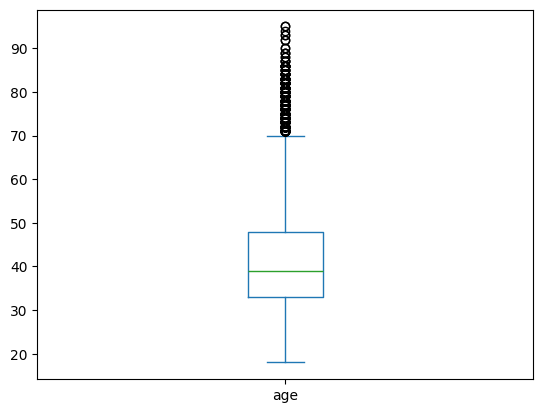

In [6]:
print(df['age'].describe())
df['age'].plot(kind='box')
plt.show()

The histogram shows that most customers fall between ages 25 and 65, with fewer observations at the extremes. Using age ranges would reduces noise from individual ages while preserving meaningful life-stage differences relevant for marketing targeting 

=> Age will be grouped into ranges based on the observed distribution to create stable and interpretable customer segments. 

In [7]:
df['age_bucket'] = pd.cut(
    df['age'],
    bins=[18,25,35,45,55,65,100],
    labels=[
        '18-25',
        '25-35',
        '35-45',
        '45-55',
        '55-65',
        '65+'
    ]
)

In [8]:
df['age_bucket'].value_counts()

age_bucket
25-35    15571
35-45    13856
45-55     9548
55-65     4149
18-25     1324
65+        751
Name: count, dtype: int64

The feature engineered dataset is saved to `data/processed/bank-full-cleaned-processed-engineered.csv` for use in downstream analysis and modeling.

In [11]:
import os

FEATURE_ENGINEERED_DATA_PATH = ROOT / "data" / "processed" / "bank-full-cleaned-processed-engineered.csv"
os.makedirs(os.path.dirname(FEATURE_ENGINEERED_DATA_PATH), exist_ok=True)
df.to_csv(FEATURE_ENGINEERED_DATA_PATH, index=False)